# Introdução à análise exploratória

## Quais dados vamos explorar?


Para dar uma breve ideia sobre o conjunto de dados, ele contém 11.914 linhas e 16 colunas, que incluem características de carros, como tipo de combustível, potência do motor (HP), tipo de transmissão, consumo na estrada, consumo na cidade, preço (MSRP) e outras.

Esse dataset pode ser usado para a predição dos preços dos carros a partir de atributos como marca, modelo, ano, potência, consumo, etc.

**Com que tipo de paradigma de aprendizado e problema esse dataset poderia ser usado?**

## 1. Importando as bibliotecas necessárias para EDA

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy import stats



---



## 2. Carregando os dados em um dataframe Pandas

In [ ]:
url = "https://raw.githubusercontent.com/zz4fap/c24_inteligencia_artificial/main/data/car_features.csv"
df = pd.read_csv(url)

# Mostrando as 5 primeiras linhas
df.head(5)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


## 3. Verificando as dimensões dos dados

In [ ]:
df.shape

(11914, 16)

## 4. Verificando os tipos dos dados

**Quais tipos temos?**

OBS.: O Pandas usa `object` quando a coluna não dá pra ser interpretada com segurança como numérica/datetime/categórica, ou quando ela é texto (`string`).

In [ ]:
df.dtypes

,0
Make,object
Model,object
Year,int64
Engine Fuel Type,object
Engine HP,float64
Engine Cylinders,float64
Transmission Type,object
Driven_Wheels,object
Number of Doors,float64
Market Category,object


## 5. Verificando as estatísticas básicas dos dados

OBS.: As estatísticas são calculadas apenas para as colunas numéricas.

**Se temos 11914 linhas, por que algumas colunas tem uma contagem menor?**

In [ ]:
df.describe()

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,11914.000000,11845.00000,11884.000000,11908.000000,11914.000000,11914.000000,11914.000000,1.191400e+04
mean,2010.384338,249.38607,5.628829,3.436093,26.637485,19.733255,1554.911197,4.059474e+04
std,7.579740,109.19187,1.780559,0.881315,8.863001,8.987798,1441.855347,6.010910e+04
min,1990.000000,55.00000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,170.00000,4.000000,2.000000,22.000000,16.000000,549.000000,2.100000e+04
50%,2015.000000,227.00000,6.000000,4.000000,26.000000,18.000000,1385.000000,2.999500e+04
75%,2016.000000,300.00000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.223125e+04
max,2017.000000,1001.00000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


Resposta: Faltam dados em algumas linhas.

## 6. Eliminando colunas irrelevantes

OBS.: a ideia é manter só o que ajuda o objetivo do problema e tirar o que atrapalha.

Alguns motivos para eliminar: IDs, timestamps, coluna com valores constantes, coluna com muitos valores faltantes, colunas redundantes, etc.

In [ ]:
df = df.drop(['Engine Fuel Type', 'Market Category', 'Vehicle Style', 'Popularity', 'Number of Doors', 'Vehicle Size'], axis=1)

df.head(5)

,Make,Model,Year,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,highway MPG,city mpg,MSRP
0,BMW,1 Series M,2011,335.0,6.0,MANUAL,rear wheel drive,26,19,46135
1,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,19,40650
2,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,20,36350
3,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,29450
4,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,34500


## 7. Renomeando colunas

A maioria dos nomes das colunas são confusos, então vamos os alterá-los.

Essa é uma boa abordagem, pois melhora a legibilidade do conjunto de dados.

In [ ]:
df = df.rename(columns={
    "Engine HP": "HP",
    "Engine Cylinders": "Cylinders",
    "Transmission Type": "Transmission",
    "Driven_Wheels": "Drive Mode",
    "highway MPG": "MPG-H",
    "city mpg": "MPG-C",
    "MSRP": "Price"
})

df.head(5)

,Make,Model,Year,HP,Cylinders,Transmission,Drive Mode,MPG-H,MPG-C,Price
0,BMW,1 Series M,2011,335.0,6.0,MANUAL,rear wheel drive,26,19,46135
1,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,19,40650
2,BMW,1 Series,2011,300.0,6.0,MANUAL,rear wheel drive,28,20,36350
3,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,29450
4,BMW,1 Series,2011,230.0,6.0,MANUAL,rear wheel drive,28,18,34500


## 8. Removendo linhas duplicadas






In [ ]:
# Quantas linhas duplicadas?
df.duplicated().sum()

np.int64(989)

In [ ]:
# Remove duplicatas.
df.drop_duplicates(inplace=True)

In [ ]:
# Quantas linhas duplicadas?
df.duplicated().sum()

np.int64(0)

Vamos contar quantos elementos por coluna.

**Existem colunas com número menor de elementos do que as outras colunas?**

**Se sim, o que pode ser?**

In [ ]:
# Count conta o número de elementos em cada coluna
df.count()

,0
Make,10925
Model,10925
Year,10925
HP,10856
Cylinders,10895
Transmission,10925
Drive Mode,10925
MPG-H,10925
MPG-C,10925
Price,10925


## 9. Tratando valores faltantes

Podemos remover as linhas com valores faltantes ou preencher os valores faltantes com a média, moda ou mediana da coluna correspondente.

Neste exemplo, como temos muitos dados e poucas linhas com elementos faltantes, apenas os removeremos.

In [ ]:
# Quantos valores estão faltando por coluna?
df.isnull().sum()

,0
Make,0
Model,0
Year,0
HP,69
Cylinders,30
Transmission,0
Drive Mode,0
MPG-H,0
MPG-C,0
Price,0


As colunas *HP* e *Cylinders* possuem valores faltantes.

### Eliminando linhas com valores faltantes

In [ ]:
# Eliminando os valores faltantes.
df.dropna(inplace=True)

In [ ]:
# Número de elementos em cada coluna após a remoção.
df.count()

,0
Make,10827
Model,10827
Year,10827
HP,10827
Cylinders,10827
Transmission,10827
Drive Mode,10827
MPG-H,10827
MPG-C,10827
Price,10827


In [ ]:
# Contagem após eliminar as linhas com elementos faltantes.
df.isnull().sum()

,0
Make,0
Model,0
Year,0
HP,0
Cylinders,0
Transmission,0
Drive Mode,0
MPG-H,0
MPG-C,0
Price,0


## 10. Detectando *outliers*

### Histograma

**OBS.: vamos plotar os histogramas de algumas variáveis numéricas.**

#### Plotando o histograma do atributo 'MPG-C'

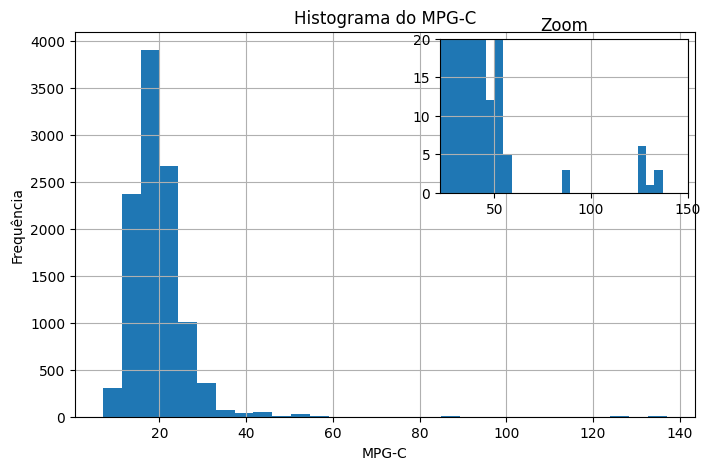

In [ ]:
# Figura principal
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(df['MPG-C'], bins=30)
ax.set_xlabel('MPG-C')
ax.set_ylabel('Frequência')
ax.set_title('Histograma do MPG-C')
ax.grid(True)

# --- INSET (zoom) ---
ax_inset = inset_axes(
    ax,
    width="40%",   # largura do inset
    height="40%",  # altura do inset
    loc="upper right"
)

# Intervalo menor
ax_inset.hist(
    df['MPG-C'],
    bins=30
)

ax_inset.set_xlim(22, 150)
ax_inset.set_ylim(0, 20)
ax_inset.set_title('Zoom')
ax_inset.grid(True)

plt.show()


#### Plotando o histograma do atributo 'Price'

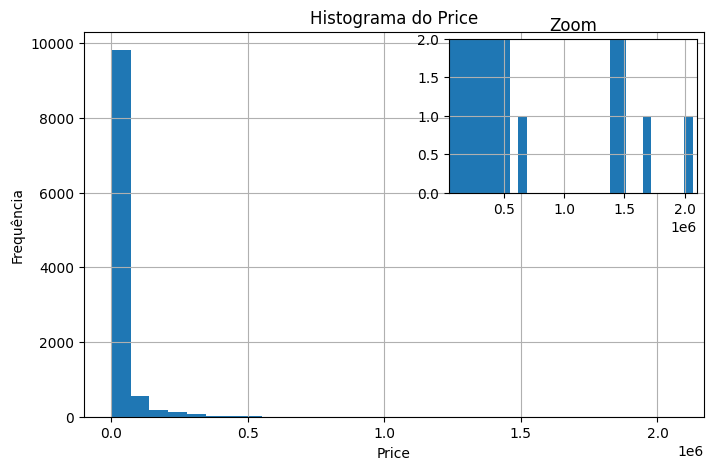

In [ ]:
# Figura principal
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(df['Price'], bins=30)
ax.set_xlabel('Price')
ax.set_ylabel('Frequência')
ax.set_title('Histograma do Price')
ax.grid(True)

# --- INSET (zoom) ---
ax_inset = inset_axes(
    ax,
    width="40%",   # largura do inset
    height="40%",  # altura do inset
    loc="upper right"
)

# Intervalo menor
ax_inset.hist(
    df['Price'],
    bins=30
)

ax_inset.set_xlim(4.330000e+04, 2.1e+06)
ax_inset.set_ylim(0, 2)
ax_inset.set_title('Zoom')
ax_inset.grid(True)

plt.show()


**Com os histogramas, não temos uma ideia muita clara se os valores são *outliers* ou não**.

**Vamos usar *boxplot* para ter uma ideia mais clara**.

### Boxplot

#### Plotando o boxplot do atributo 'MPG-C'

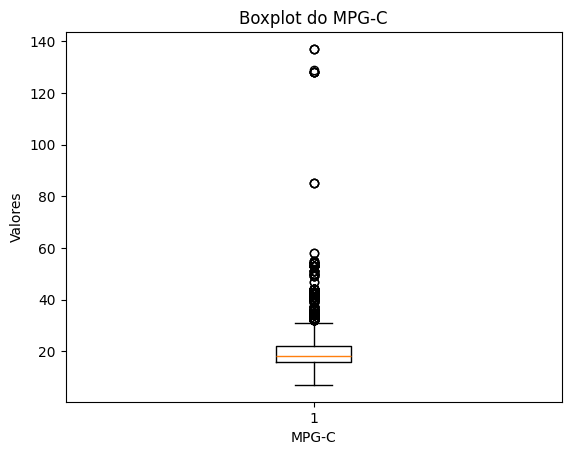

In [ ]:
plt.boxplot(df['MPG-C'])
plt.xlabel('MPG-C')
plt.ylabel('Valores')
plt.title('Boxplot do MPG-C')
plt.show()

**Existem *outliers* no atributo MPG-C?**

Do ponto de vista estatístico, podemos dizer que existem outliers segundo o critério da distância interquartil (1.5 * IQR).

Valores moderadamente altos (30–50 MPG) podem ser plausíveis, dependendo do tipo de veículo: híbridos, veículos muito eficientes, condições específicas de medição.

Valores extremamente altos (> 50 MPG) são altamente suspeitos. Eles estão muito fora da escala física esperada para consumo na cidade. Eles normalmente indicam: erro de registro, conversão incorreta de unidades, valor agregado / estimado, dado corrompido.

Veredito: Como os dados são antigos, eles não contemplam dados de carros elétricos, portanto, devemos remover valores maiores do que 50 MPG. Além disso, mesmo sendo o consumo na cidade, carros a combustão apresentam MPG inferior a 50.

#### Plotando o boxplot do atributo 'Price'

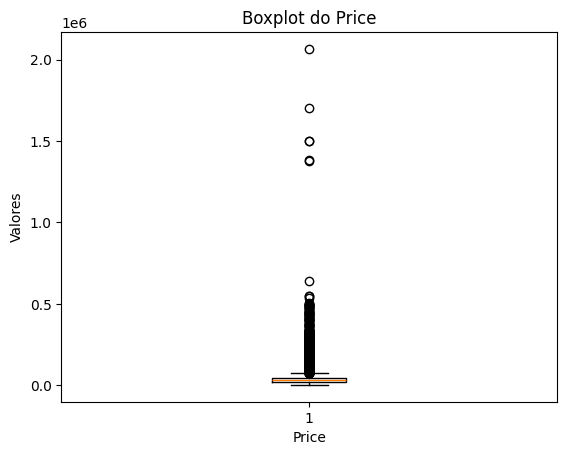

In [ ]:
plt.boxplot(df['Price'])
plt.xlabel('Price')
plt.ylabel('Valores')
plt.title('Boxplot do Price')
plt.show()

**Existem *outliers* no atributo Price?**

Do ponto de vista estatístico, podemos dizer que existem outliers segundo o critério da distância interquartil (1.5 * IQR).

O dataset contém desde carros populares e de entrada até modelos de luxo e exóticos. Alguns exemplos do *dataset*:
+ BMW 1 Series: Na casa dos \$30.000 - \$45.000
+ BMW Z8: Saltando para \$130.000
+ Bugatti Veyron: custando mais de \$2.000.000

Esses valores são de carros de luxo, mas reais e não devem ser removidos.

O histograma mostra uma "cauda" longa que se estende para a direita (distribuição com assemetria positiva).

Veredito: mantê-los.

## 11. Removendo *outliers*

### Removendo *outliers* do atributo `MPG-C` usando IQR.

In [ ]:
Q1 = df['MPG-C'].quantile(0.25)
Q3 = df['MPG-C'].quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

df_sem_outliers_iqr = df[
    (df['MPG-C'] >= lim_inf) &
    (df['MPG-C'] <= lim_sup)
]

Boxplot do atributo `MPG-H` sem *outliers*.

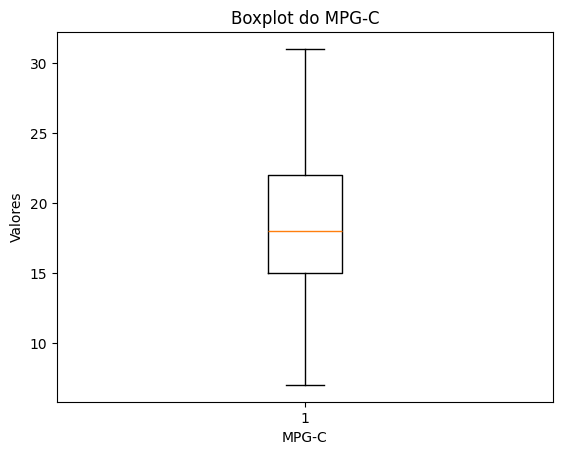

In [ ]:
plt.boxplot(df_sem_outliers_iqr['MPG-C'])
plt.xlabel('MPG-C')
plt.ylabel('Valores')
plt.title('Boxplot do MPG-C')
plt.show()

## 12. Relação entre variáveis

### Mariz de correlação (*heatmap*)

#### Usando o coeficiente de Pearson.

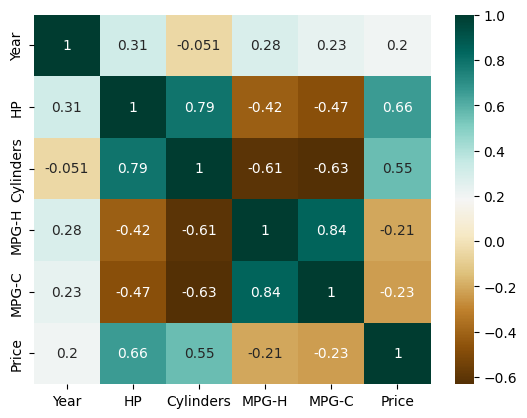

In [ ]:
corr = df.corr(method='pearson', numeric_only=True)

plt.figure()
sns.heatmap(corr, cmap="BrBG", annot=True)
plt.show()

No mapa de calor acima, podemos ver que o preço (Price) depende principalmente da potência (HP em cavalos) e do número de cilindros.

Existem corelações bastante altas entre os atributos:
+ MPG-C e MPG-H
+ HP e Cilindros

Talvez possamos ficar com apenas uma delas.

### Diagrama de dispersão (*scatterplot*)

Geralmente, usamos diagramas de dispersão para encontrar a correlação entre duas variáveis.

#### Diagrama de dispersão entre a potência (`HP`) e o preço (`Price`).

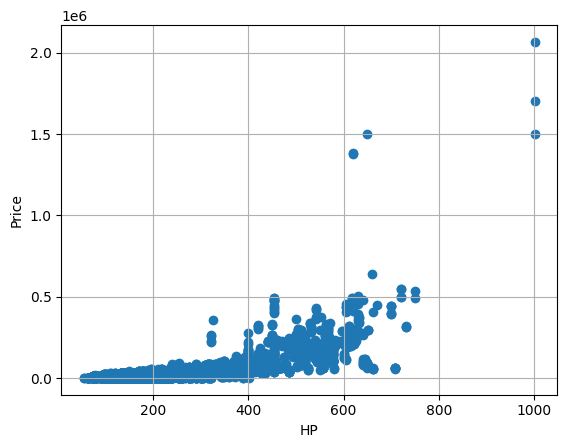

In [ ]:
fig, ax = plt.subplots()
ax.scatter(df['HP'], df['Price'])
ax.set_xlabel('HP')
ax.set_ylabel('Price')
ax.grid(True)
plt.show()

Existe uma relação entre as duas variáveis, mas nitidamente não é linear.

Se o valor de uma variável aumenta, a outra tende a aumentar, não na mesma taxa, mas aumenta.

#### Diagrama de dispersão entre o consumo (`MPG-H`) na estrada e o consumo na cidade (`MPG-C`).

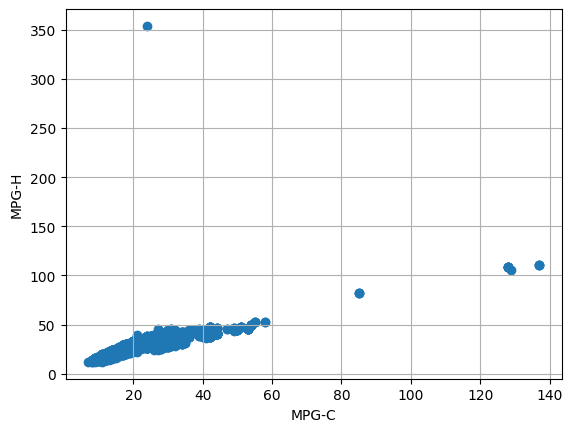

In [ ]:
fig, ax = plt.subplots()
ax.scatter(df['MPG-C'], df['MPG-H'])
ax.set_xlabel('MPG-C')
ax.set_ylabel('MPG-H')
ax.grid(True)
plt.show()

Coeficiente de Pearson é alto.

A relação é bastante linear, o que é esperado.

Presença de *outlier* : `MPG-H` $\approx$ 350.



### *Pairplot* (ou matriz *scatterplot*)

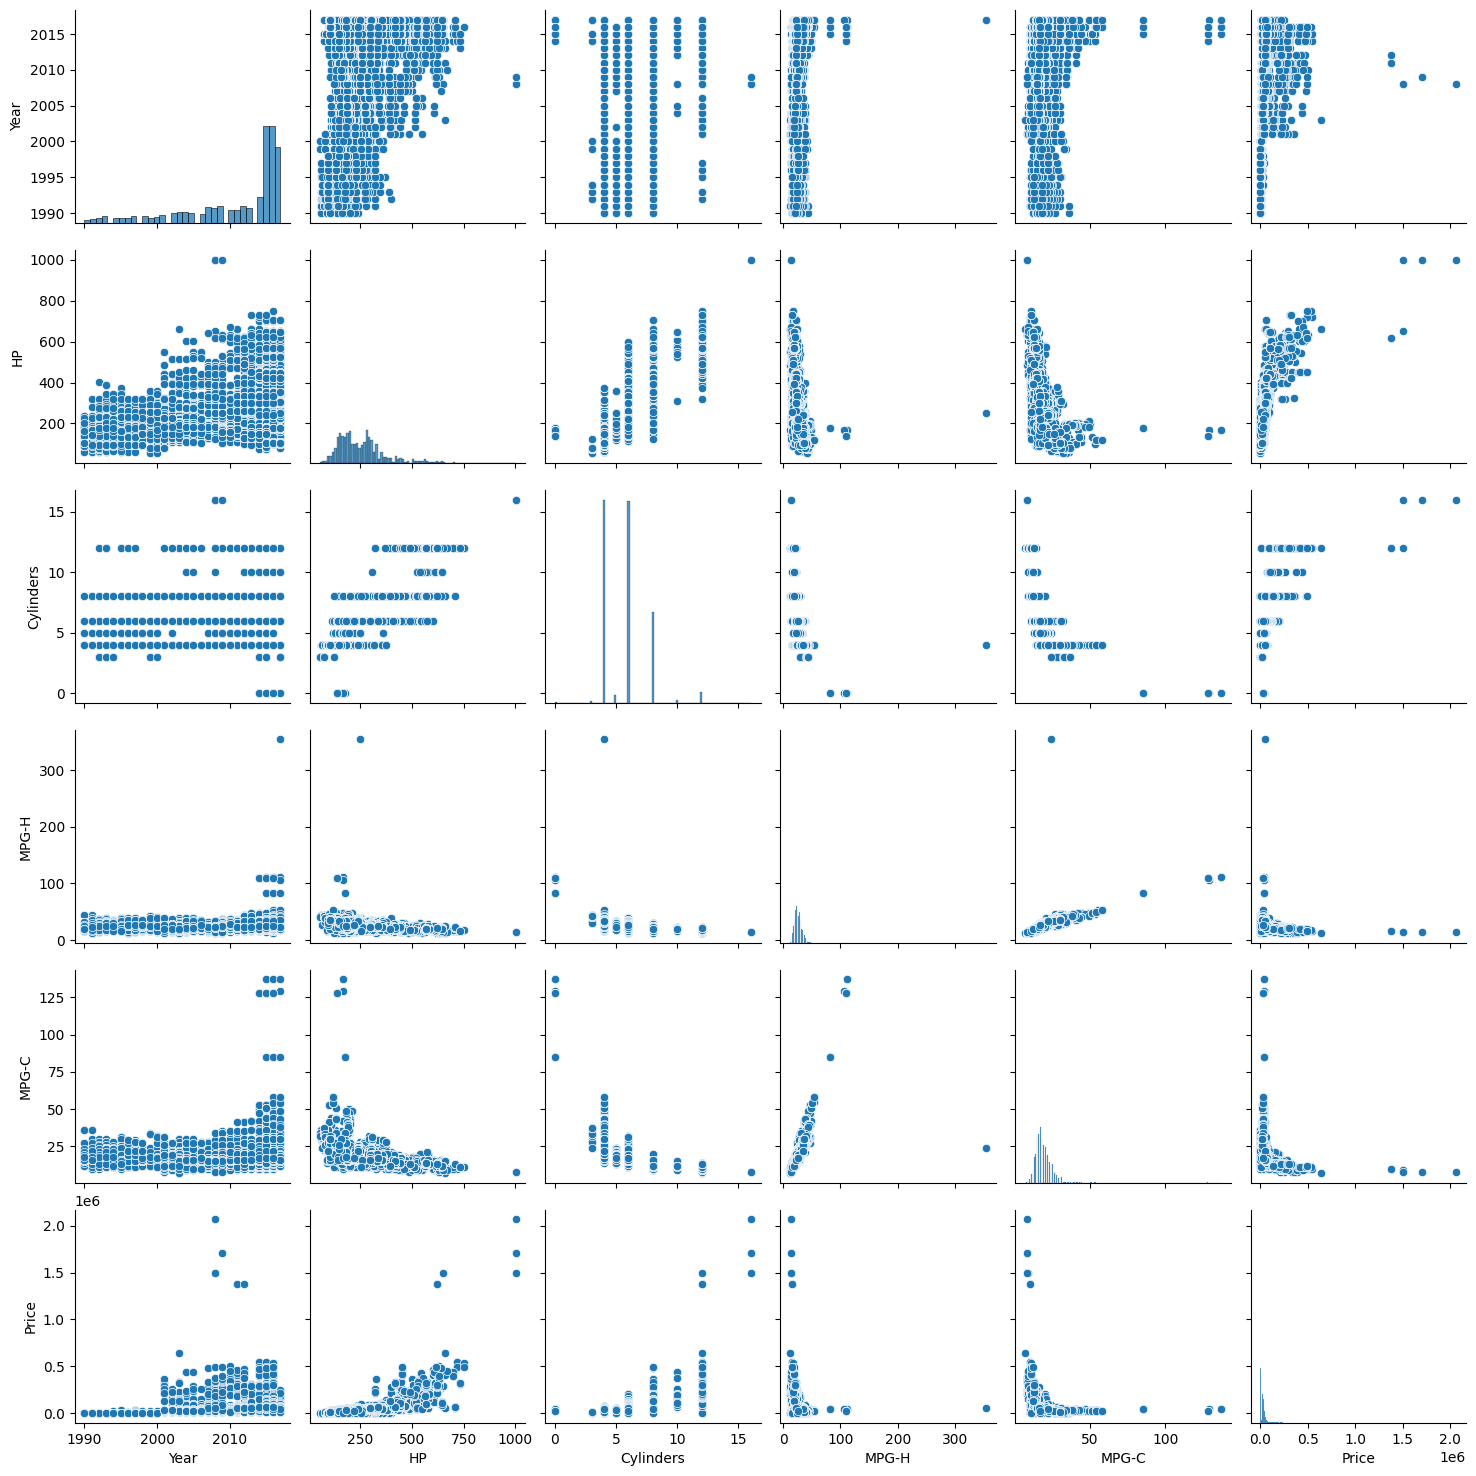

In [ ]:
sns.pairplot(df)
plt.show()


**Estes foram alguns dos passos que vocês devem seguir para realizar uma análise exploratória de dados (EDA).**

**Existem outros passos, mas estes são mais do que suficientes para ter uma boa ideia de como realizar uma EDA com qualquer conjunto de dados.**